In [13]:
import sys
!{sys.executable} -m pip install --user stardist csbdeep tensorflow tifffile scikit-image matplotlib

In [14]:
#IMPORTS 
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import csv

from csbdeep.utils import normalize
from stardist.models import StarDist2D
from skimage.color import label2rgb

In [15]:
base_dir = Path.cwd()

data_dir = base_dir / "resonant"   # change if needed
out_dir = base_dir / "stardist_results"
out_dir.mkdir(exist_ok=True)

print("Data dir:", data_dir)
print("Output dir:", out_dir)

Data dir: /scratch/user/s4906996/Cellpose SAM/resonant
Output dir: /scratch/user/s4906996/Cellpose SAM/stardist_results


In [16]:
def pick_2d_for_stardist(img, method="median"):
    """
    Convert resonant TIFF to one 2D image for StarDist.
    """
    if img.ndim == 2:
        im2d = img
    elif img.ndim == 3:
        if method == "mean":
            im2d = img.mean(axis=0)
        elif method == "median":
            im2d = np.median(img, axis=0)
        elif method == "middle":
            im2d = img[img.shape[0] // 2]
        else:
            raise ValueError("method must be mean / median / middle")
    else:
        raise ValueError(f"Unsupported shape: {img.shape}")

    return im2d.astype(np.float32)


def remove_small_labels(label_img, min_area=80):
    """
    Remove tiny segmented objects by area.
    Relabel remaining objects to 1..N.
    """
    filtered = np.zeros_like(label_img, dtype=np.uint16)
    props = regionprops(label_img)

    new_id = 1
    for r in props:
        if r.area >= min_area:
            filtered[label_img == r.label] = new_id
            new_id += 1

    return filtered

In [17]:
#loding pre-trained stardist model 
model = StarDist2D.from_pretrained('2D_versatile_fluo')
print("Loaded StarDist pretrained model")

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Loaded StarDist pretrained model


Found TIFF files: 22
Example file: 614399S2D20250113.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07303370535373688..1.8179774045944215].


Detected objects: 81


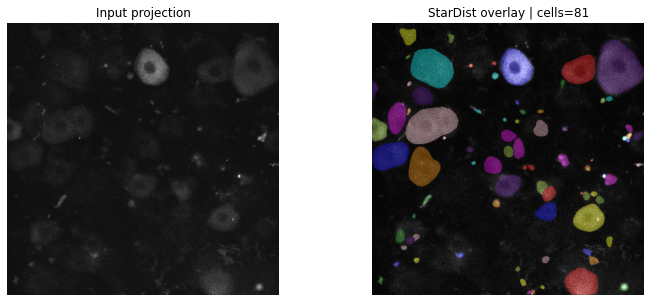

In [18]:
#testing on one resonant image 
tiff_files = sorted(
    [f for f in data_dir.glob("*.tif") if not f.name.startswith(".")] +
    [f for f in data_dir.glob("*.tiff") if not f.name.startswith(".")]
)

print("Found TIFF files:", len(tiff_files))
print("Example file:", tiff_files[0].name)

test_fp = tiff_files[0]
img = tifffile.imread(test_fp)

im2d = pick_2d_for_stardist(img, method="mean")
im_norm = normalize(im2d, 1, 99.8)

labels, details = model.predict_instances(im_norm)

print("Detected objects:", int(labels.max()))

overlay = label2rgb(labels, image=im_norm, bg_label=0, alpha=0.35)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(im_norm, cmap="gray")
plt.title("Input projection")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title(f"StarDist overlay | cells={int(labels.max())}")
plt.axis("off")
plt.show()

In [19]:
#batch running on all resonant images 
results = []
failed = []

PROJ_METHOD = "mean"   # try "median" too
USE_TILES = False      # set True if memory becomes an issue

for fp in tiff_files:
    try:
        print(f"Processing: {fp.name}")

        img = tifffile.imread(fp)
        im2d = pick_2d_for_stardist(img, method=PROJ_METHOD)
        im_norm = normalize(im2d, 1, 99.8)

        if USE_TILES:
            labels, details = model.predict_instances(im_norm, n_tiles=(2,2))
        else:
            labels, details = model.predict_instances(im_norm)

        n_cells = int(labels.max())

        # save mask
        mask_out = out_dir / f"{fp.stem}_stardist_masks.tif"
        tifffile.imwrite(mask_out, labels.astype(np.uint16))

        # save overlay
        overlay = label2rgb(labels, image=im_norm, bg_label=0, alpha=0.35)
        overlay_out = out_dir / f"{fp.stem}_stardist_overlay.png"

        plt.figure(figsize=(7,7))
        plt.imshow(overlay)
        plt.title(f"{fp.name} | StarDist cells={n_cells}")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(overlay_out, dpi=200, bbox_inches="tight")
        plt.close()

        results.append([fp.name, n_cells])
        print(f"  Saved mask and overlay | cells={n_cells}")

    except Exception as e:
        failed.append([fp.name, str(e)])
        print(f"  Failed: {e}")

Processing: 614399S2D20250113.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07303370535373688..1.8179774045944215].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06893939524888992..3.0189391136169434].


  Saved mask and overlay | cells=81
Processing: 614399s1d120250113.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04498917981982231..1.3127685546875].


  Saved mask and overlay | cells=97
Processing: 614399s1d20241213.tif


...

  Saved mask and overlay | cells=36
Processing: 671485s2d20250728.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06499999761581421..1.3683333158493043].


  Saved mask and overlay | cells=41
Processing: 671486s1d20250728.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011271676048636436..1.1512282848358155].


  Saved mask and overlay | cells=80
Processing: 671488s1d20250326.tif
  Saved mask and overlay | cells=38
